# Pertemuan 9 — Algoritma Klasifikasi (Bagian 1): Logistic Regression & Decision Tree

**Mata Kuliah:** Pengantar Data Science (Kode: 200302305)  
**Program Studi:** PJJ Informatika  
**Semester:** 4  
**Dosen:** Syahid Abdullah, S.Si, M.Kom

---

**Nama :** Junior Dany Wibisono  
**NIM  :** 250401020098  
**Kelas :** IF401  
**Angkatan:** 2025  
**Tanggal:** 28 Juni 2026

---

## Tujuan Notebook
Aktivitas hands-on Pertemuan 9 — membangun & membandingkan **dua model klasifikasi** untuk memprediksi diagnosis kanker payudara (dataset *Breast Cancer Wisconsin*):
1. Load dataset & EDA singkat (distribusi kelas malignant/benign)
2. Preprocessing: train-test split **stratify** + StandardScaler (anti *data leakage*)
3. Melatih **Logistic Regression** & menginterpretasikan koefisien
4. Melatih **Decision Tree** (`max_depth=4`), memvisualisasikan pohon & `feature_importances_`
5. Evaluasi dengan **Confusion Matrix, Accuracy, Precision, Recall, F1-Score** untuk kedua model
6. Eksplorasi pengaruh **threshold** terhadap Recall pada konteks medis

> **Konteks medis (penting):** pada dataset ini target bernilai `0 = Malignant (ganas)` dan `1 = Benign (jinak)`. Kesalahan paling berbahaya adalah **False Negative** — kasus **ganas** yang lolos terdeteksi sebagai jinak. Karena itu **Recall pada kelas Malignant** menjadi metrik paling kritis sepanjang notebook ini.

## Langkah 1 — Load Dataset & EDA Singkat

Dataset **Breast Cancer Wisconsin** adalah dataset bawaan scikit-learn (`load_breast_cancer`) yang populer untuk klasifikasi biner di domain medis:
- **569 sampel**, **30 fitur numerik** (ukuran & tekstur inti sel: *radius, texture, area, concavity*, dst.; masing-masing dalam tiga ringkasan: *mean, error, worst*)
- **Target (y):** `0 = Malignant` (ganas) · `1 = Benign` (jinak)

EDA singkat: cek dimensi data, **distribusi kelas** (seimbang atau tidak?), dan **korelasi** beberapa fitur kunci terhadap diagnosis.

In [11]:
# Langkah 1: Load dataset Breast Cancer Wisconsin & EDA singkat
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='diagnosis')   # 0 = Malignant (ganas), 1 = Benign (jinak)

print('Shape fitur (X):', X.shape, '->', X.shape[0], 'sampel,', X.shape[1], 'fitur')
print('Nama kelas (target_names):', list(data.target_names), '(indeks 0=malignant, 1=benign)')
print()
dist = y.value_counts().sort_index()
prop = y.value_counts(normalize=True).sort_index()
print('Distribusi target:')
print(f'  0 = Malignant (ganas) : {dist[0]:>3} sampel ({prop[0]*100:.1f}%)')
print(f'  1 = Benign   (jinak)  : {dist[1]:>3} sampel ({prop[1]*100:.1f}%)')
print()
print('Cuplikan 5 fitur pertama (3 baris):')
print(X.iloc[:3, :5].round(2).to_string())

Shape fitur (X): (569, 30) -> 569 sampel, 30 fitur
Nama kelas (target_names): [np.str_('malignant'), np.str_('benign')] (indeks 0=malignant, 1=benign)

Distribusi target:
  0 = Malignant (ganas) : 212 sampel (37.3%)
  1 = Benign   (jinak)  : 357 sampel (62.7%)

Cuplikan 5 fitur pertama (3 baris):
   mean radius  mean texture  mean perimeter  mean area  mean smoothness
0        17.99         10.38           122.8     1001.0             0.12
1        20.57         17.77           132.9     1326.0             0.08
2        19.69         21.25           130.0     1203.0             0.11


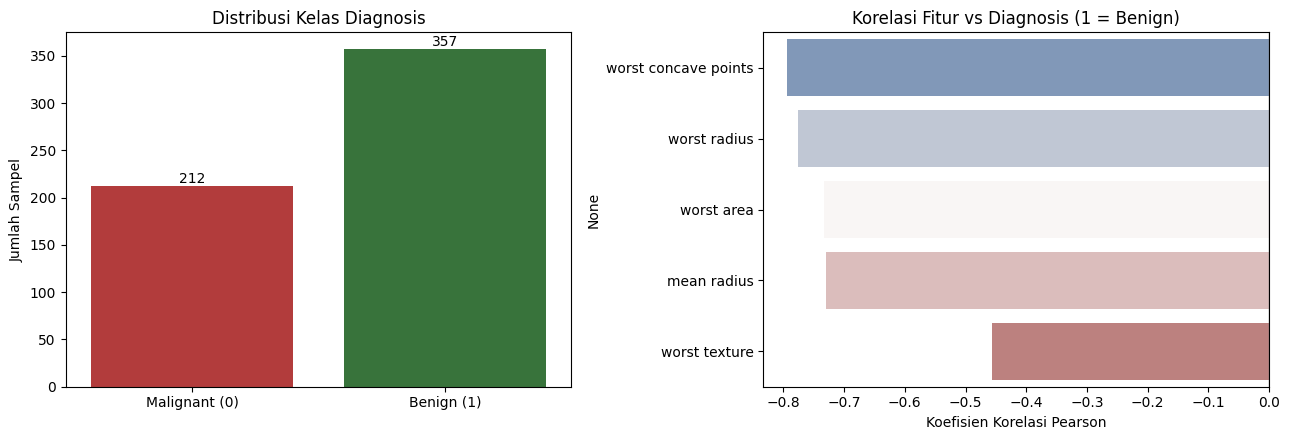

In [12]:
# Visualisasi EDA: distribusi kelas & korelasi fitur terpilih dengan diagnosis
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# (1) Distribusi kelas target
sns.countplot(x=y, hue=y, order=[0, 1],
              palette=['#C62828', '#2E7D32'], legend=False, ax=axes[0])
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(['Malignant (0)', 'Benign (1)'])
axes[0].set_title('Distribusi Kelas Diagnosis')
axes[0].set_xlabel(''); axes[0].set_ylabel('Jumlah Sampel')
for p in axes[0].patches:
    axes[0].annotate(int(p.get_height()),
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom')

# (2) Korelasi beberapa fitur ukuran sel dengan target (1 = Benign)
feats = ['worst radius', 'worst concave points', 'worst area',
         'worst texture', 'mean radius']
corr = (pd.concat([X[feats], y], axis=1)
        .corr(numeric_only=True)['diagnosis'].drop('diagnosis').sort_values())
sns.barplot(x=corr.values, y=corr.index, hue=corr.index,
            palette='vlag', legend=False, ax=axes[1])
axes[1].axvline(0, color='gray', lw=1)
axes[1].set_title('Korelasi Fitur vs Diagnosis (1 = Benign)')
axes[1].set_xlabel('Koefisien Korelasi Pearson')

plt.tight_layout(); plt.show()

**Bacaan EDA:**
- **Distribusi kelas:** 357 *Benign* (62,7%) vs 212 *Malignant* (37,3%) — **sedikit tidak seimbang** (rasio ≈ 1,7 : 1), namun belum termasuk *imbalance* ekstrem. Karena ada ketidakseimbangan ringan, **Accuracy saja tidak cukup**; kita tetap perlu Precision/Recall/F1.
- **Korelasi fitur:** seluruh fitur ukuran sel (*worst radius, worst area, worst concave points*, dst.) berkorelasi **negatif** terhadap target (1 = Benign). Artinya **semakin besar/tidak beraturan inti sel, semakin kecil peluang Benign** — alias semakin mengarah ke **Malignant**. Ini sesuai intuisi medis dan menjustifikasi kedua model untuk menangkap pola tersebut.

## Langkah 2 — Preprocessing

Urutan yang benar untuk **mencegah data leakage**:
1. **Train-Test Split 80:20** dengan `stratify=y` agar **proporsi kelas** malignant/benign tetap terjaga di train maupun test.
2. **StandardScaler**: `fit_transform` **hanya** di data train, lalu `transform` di test.

> Catatan: *scaling* **wajib** untuk Logistic Regression (mempercepat konvergensi & menyamakan skala 30 fitur), tetapi **tidak diperlukan** untuk Decision Tree (split berbasis ambang, invarian terhadap skala). Karena itu kita siapkan **dua versi data**: terstandarisasi (untuk LogReg) dan asli (untuk Tree).

In [13]:
# Langkah 2: Train-Test Split (80:20, stratify) + StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   # fit + transform HANYA di train
X_test_s  = scaler.transform(X_test)        # test: transform saja (anti data leakage)

print(f'Train : {X_train.shape[0]} sampel | Test : {X_test.shape[0]} sampel')
print('Proporsi kelas TERJAGA berkat stratify=y:')
print('  Train ->', y_train.value_counts(normalize=True).sort_index().round(3).to_dict())
print('  Test  ->', y_test.value_counts(normalize=True).sort_index().round(3).to_dict())
print()
print('Data siap: X_train_s/X_test_s (terstandarisasi) untuk LogReg;')
print('           X_train/X_test (asli) untuk Decision Tree.')

Train : 455 sampel | Test : 114 sampel
Proporsi kelas TERJAGA berkat stratify=y:
  Train -> {0: 0.374, 1: 0.626}
  Test  -> {0: 0.368, 1: 0.632}

Data siap: X_train_s/X_test_s (terstandarisasi) untuk LogReg;
           X_train/X_test (asli) untuk Decision Tree.


## Langkah 3 — Latih Logistic Regression

Logistic Regression mengubah kombinasi linear fitur menjadi probabilitas via **fungsi sigmoid** σ(z) = 1 / (1 + e^(−z)), lalu memutuskan kelas dengan *threshold* (default 0,5). Kita pakai data **terstandarisasi** dan `max_iter=5000` agar optimasi konvergen penuh. Koefisien β menunjukkan arah & kekuatan pengaruh tiap fitur (dalam satuan **standar deviasi**, karena fitur sudah di-*scale*).

In [14]:
# Langkah 3: Latih Logistic Regression & tampilkan koefisien
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=5000, random_state=42)
log_model.fit(X_train_s, y_train)
y_pred_log = log_model.predict(X_test_s)

print(f'b0 (intercept): {log_model.intercept_[0]:.3f}')
print()
coef_df = pd.DataFrame({'Fitur': X.columns, 'Koefisien': log_model.coef_[0]})
coef_df['|Koefisien|'] = coef_df['Koefisien'].abs()
coef_df = coef_df.sort_values('|Koefisien|', ascending=False)
print('8 fitur paling berpengaruh (|koefisien| terbesar):')
print(coef_df.head(8).to_string(index=False))

b0 (intercept): 0.302

8 fitur paling berpengaruh (|koefisien| terbesar):
               Fitur  Koefisien  |Koefisien|
       worst texture  -1.255088     1.255088
        radius error  -1.082965     1.082965
worst concave points  -0.953686     0.953686
          worst area  -0.947756     0.947756
        worst radius  -0.947616     0.947616
      worst symmetry  -0.939181     0.939181
          area error  -0.929104     0.929104
     worst concavity  -0.823151     0.823151


**Interpretasi koefisien** (ingat: target `1 = Benign`, fitur sudah **distandarisasi**):

- Semua fitur teratas memiliki **koefisien negatif**. Karena kelas positif default adalah **Benign (1)**, koefisien negatif berarti: **semakin besar nilai fitur → semakin kecil peluang Benign → semakin mengarah ke Malignant**.
- **`worst texture` (−1,26)**, **`radius error` (−1,08)**, **`worst concave points` (−0,95)**, serta **`worst area`/`worst radius` (≈ −0,95)** adalah pendorong terkuat ke arah diagnosis **ganas**. Konsisten dengan pengetahuan medis: inti sel yang **lebih besar, lebih bertekstur, dan lebih banyak titik cekung** cenderung ganas.
- Model berhasil menangkap struktur yang juga terlihat pada korelasi EDA (fitur ukuran berkorelasi negatif dengan Benign).

## Langkah 4 — Latih Decision Tree

Decision Tree membangun **aturan if-else bertingkat**, memilih split yang paling menurunkan **Gini Impurity**. Kita batasi `max_depth=4` untuk **mencegah overfitting** (pohon tanpa batas cenderung menghafal data). Decision Tree **tidak butuh scaling**, jadi dilatih pada **data asli** `X_train`. Atribut `feature_importances_` mengungkap fitur paling berpengaruh, dan `plot_tree` membuat modelnya **dapat dibaca manusia**.

In [15]:
# Langkah 4: Latih Decision Tree (max_depth=4, TANPA scaling) + feature importance
from sklearn.tree import DecisionTreeClassifier, plot_tree

tree_model = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_model.fit(X_train, y_train)             # data ASLI - Decision Tree tidak butuh scaling
y_pred_tree = tree_model.predict(X_test)

print(f'Kedalaman pohon : {tree_model.get_depth()} | Jumlah leaf : {tree_model.get_n_leaves()}')
print()
imp_df = pd.DataFrame({'Fitur': X.columns,
                       'Importance': tree_model.feature_importances_}
                      ).sort_values('Importance', ascending=False)
print('5 fitur paling penting (feature_importances_):')
print(imp_df.head(5).to_string(index=False))

Kedalaman pohon : 4 | Jumlah leaf : 11

5 fitur paling penting (feature_importances_):
               Fitur  Importance
        worst radius    0.733548
worst concave points    0.122028
       texture error    0.045785
       worst texture    0.032319
     worst concavity    0.017161


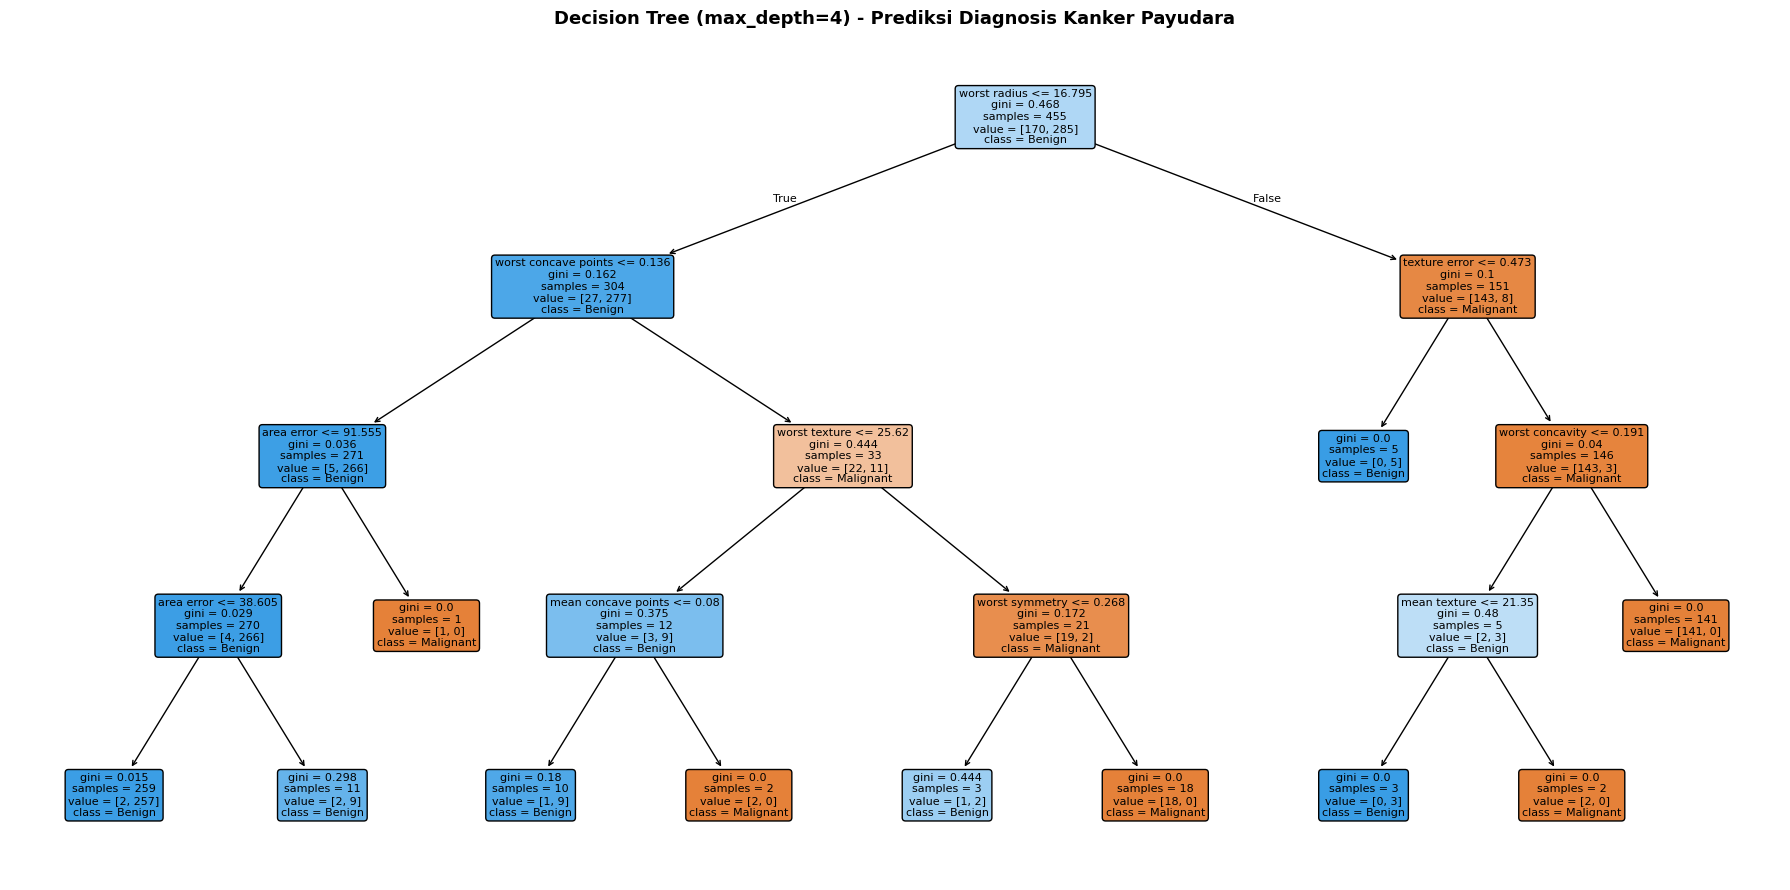

In [16]:
# Visualisasi struktur Decision Tree
plt.figure(figsize=(18, 9))
plot_tree(tree_model, feature_names=X.columns,
          class_names=['Malignant', 'Benign'], filled=True,
          rounded=True, fontsize=8)
plt.title('Decision Tree (max_depth=4) - Prediksi Diagnosis Kanker Payudara',
          fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

**Interpretasi Decision Tree:**
- **Root node** melakukan split pada **`worst radius ≤ 16,80`** — fitur yang sama dominannya pada `feature_importances_` (**0,73**, jauh di atas sisanya). Artinya **ukuran inti sel terbesar** adalah pembeda paling kuat antara ganas dan jinak.
- Dua fitur teratas (**`worst radius` 0,73** dan **`worst concave points` 0,12**) menyumbang **±86%** total importance — pohon ini bertumpu pada sedikit fitur kunci sehingga **mudah ditafsirkan**.
- Pohon berkedalaman 4 (11 leaf) cukup ringkas: tiap jalur root → leaf dapat dibaca sebagai satu **aturan diagnosis** (mis. *jika worst radius kecil & worst concave points kecil → cenderung Benign*).

## Langkah 5 — Evaluasi & Bandingkan Kedua Model

Kita hitung **Confusion Matrix** dan keempat metrik untuk **LogReg** dan **Tree**.

> **Perhatian penting (sering terlewat):** secara *default* scikit-learn menganggap **kelas 1 (Benign) sebagai kelas positif**, sehingga `precision_score`/`recall_score`/`f1_score` tanpa argumen menghitung metrik untuk **Benign**. Padahal yang berbahaya secara medis adalah **melewatkan Malignant**. Karena itu kita tampilkan **`classification_report` per kelas** *dan* metrik khusus **kelas Malignant** (`pos_label=0`) agar perbandingan Recall benar-benar relevan dengan konteks kanker.

In [17]:
# Langkah 5a: Confusion Matrix & classification_report (per kelas) untuk KEDUA model
from sklearn.metrics import (confusion_matrix, accuracy_score,
                             precision_score, recall_score, f1_score,
                             classification_report)

models = [('Logistic Regression', y_pred_log), ('Decision Tree', y_pred_tree)]
for name, y_pred in models:
    cm = confusion_matrix(y_test, y_pred)   # baris=Aktual, kolom=Prediksi; indeks 0=Malig, 1=Benign
    print(f'================== {name} ==================')
    print('Confusion Matrix           Pred: Malig   Pred: Benign')
    print(f'   Aktual: Malignant (0)        {cm[0,0]:>4}          {cm[0,1]:>4}')
    print(f'   Aktual: Benign    (1)        {cm[1,0]:>4}          {cm[1,1]:>4}')
    print(f'   -> Kanker terlewat (False Negative medis) = {cm[0,1]}  |  False alarm = {cm[1,0]}')
    print()
    print(classification_report(y_test, y_pred,
                                target_names=['Malignant (0)', 'Benign (1)'], digits=3))

================== Logistic Regression ==================
Confusion Matrix           Pred: Malig   Pred: Benign
   Aktual: Malignant (0)          41             1
   Aktual: Benign    (1)           1            71
   -> Kanker terlewat (False Negative medis) = 1  |  False alarm = 1

               precision    recall  f1-score   support

Malignant (0)      0.976     0.976     0.976        42
   Benign (1)      0.986     0.986     0.986        72

     accuracy                          0.982       114
    macro avg      0.981     0.981     0.981       114
 weighted avg      0.982     0.982     0.982       114

================== Decision Tree ==================
Confusion Matrix           Pred: Malig   Pred: Benign
   Aktual: Malignant (0)          39             3
   Aktual: Benign    (1)           4            68
   -> Kanker terlewat (False Negative medis) = 3  |  False alarm = 4

               precision    recall  f1-score   support

Malignant (0)      0.907     0.929     0.918     

In [18]:
# Langkah 5b: Tabel ringkas perbandingan - fokus pada kelas Malignant (medis)
def ringkas(y_true, y_pred, label):
    return {
        'Model': label,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Recall_Benign(1)*':  recall_score(y_true, y_pred, pos_label=1),    # default sklearn
        'Recall_Malig(0)':    recall_score(y_true, y_pred, pos_label=0),    # fokus medis
        'Precision_Malig(0)': precision_score(y_true, y_pred, pos_label=0),
        'F1_Malig(0)':        f1_score(y_true, y_pred, pos_label=0),
    }

summary = pd.DataFrame([ringkas(y_test, y_pred_log, 'Logistic Regression'),
                        ringkas(y_test, y_pred_tree, 'Decision Tree')])
print(summary.round(3).to_string(index=False))
print()
print('* Recall_Benign(1) = nilai default scikit-learn (pos_label=1). Untuk kasus kanker,')
print('  yang relevan adalah Recall_Malig(0): proporsi kasus GANAS yang berhasil terdeteksi.')

              Model  Accuracy  Recall_Benign(1)*  Recall_Malig(0)  Precision_Malig(0)  F1_Malig(0)
Logistic Regression     0.982              0.986            0.976               0.976        0.976
      Decision Tree     0.939              0.944            0.929               0.907        0.918

* Recall_Benign(1) = nilai default scikit-learn (pos_label=1). Untuk kasus kanker,
  yang relevan adalah Recall_Malig(0): proporsi kasus GANAS yang berhasil terdeteksi.


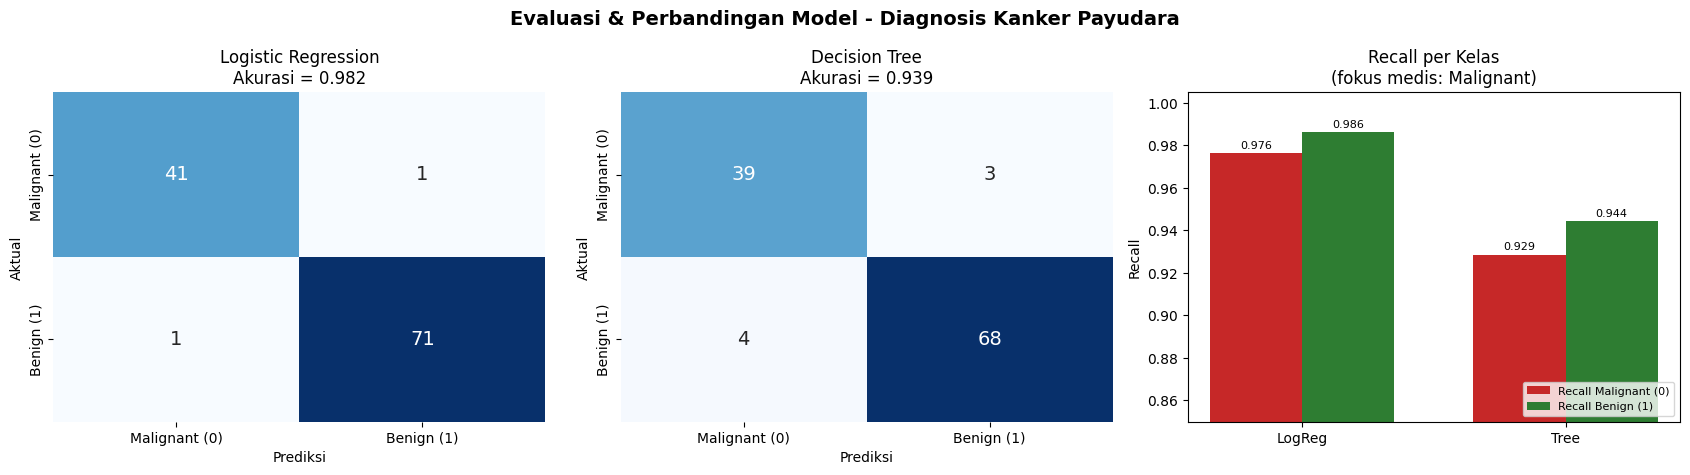

In [19]:
# Langkah 5c: Visualisasi Confusion Matrix kedua model + perbandingan Recall per kelas
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
labels = ['Malignant (0)', 'Benign (1)']

for ax, (name, y_pred) in zip(axes[:2], models):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=labels, yticklabels=labels, ax=ax,
                annot_kws={'size': 14})
    ax.set_title(f'{name}\nAkurasi = {accuracy_score(y_test, y_pred):.3f}')
    ax.set_xlabel('Prediksi'); ax.set_ylabel('Aktual')

rec_mal = [recall_score(y_test, p, pos_label=0) for _, p in models]
rec_ben = [recall_score(y_test, p, pos_label=1) for _, p in models]
xpos = np.arange(2); w = 0.35
b1 = axes[2].bar(xpos - w/2, rec_mal, w, label='Recall Malignant (0)', color='#C62828')
b2 = axes[2].bar(xpos + w/2, rec_ben, w, label='Recall Benign (1)', color='#2E7D32')
axes[2].set_xticks(xpos); axes[2].set_xticklabels(['LogReg', 'Tree'])
axes[2].set_ylim(0.85, 1.005); axes[2].set_ylabel('Recall')
axes[2].set_title('Recall per Kelas\n(fokus medis: Malignant)')
axes[2].legend(fontsize=8, loc='lower right')
axes[2].bar_label(b1, fmt='%.3f', padding=2, fontsize=8)
axes[2].bar_label(b2, fmt='%.3f', padding=2, fontsize=8)

plt.suptitle('Evaluasi & Perbandingan Model - Diagnosis Kanker Payudara',
             fontweight='bold', fontsize=14)
plt.tight_layout(); plt.show()

**Interpretasi & Jawaban Pertanyaan Aktivitas (What? So what? Now what?):**

- **What? — Model mana yang lebih baik?** **Logistic Regression unggul di semua metrik.** Akurasi **0,982 vs 0,939**, dan yang terpenting **Recall kelas Malignant 0,976 vs 0,929**. Pada 42 kasus ganas di data uji, **LogReg hanya melewatkan 1 kanker** (FN = 1), sedangkan **Decision Tree melewatkan 3** (FN = 3).
- **So what? — Mengapa Recall (Malignant) lebih kritis daripada Accuracy semata?** Dalam diagnosis kanker, **False Negative = pasien ganas divonis jinak → kanker tidak tertangani → berakibat fatal**. Sebaliknya, False Positive hanya memicu pemeriksaan lanjutan yang tidak nyaman, tetapi tidak mematikan. Accuracy memperlakukan kedua kesalahan **setara**, padahal dampaknya jauh berbeda; apalagi dengan kelas yang sedikit timpang, akurasi tinggi bisa **menutupi** kanker yang terlewat. Karena itu **Recall pada kelas Malignant** adalah metrik keputusan utama di sini.
- **Now what?** Pilih **Logistic Regression** sebagai model dasar. Untuk menekan FN lebih jauh, kita bisa **menggeser threshold** (langkah berikut), mencoba model *ensemble* (Random Forest), dan menerapkan **cross-validation** agar hasil tidak bergantung pada satu *split* acak.

## Eksplorasi Tambahan — Pengaruh *Threshold* terhadap Recall (opsional)

Logistic Regression menghasilkan **probabilitas**, bukan langsung kelas. Default `predict` memutuskan **Malignant** bila P(Malignant) ≥ 0,5. Untuk skrining kanker, kita bisa **menurunkan threshold** agar model **lebih agresif menandai ganas** — menaikkan Recall (lebih sedikit kanker terlewat) dengan konsekuensi Precision turun (lebih banyak *false alarm*). Mari ukur trade-off ini secara langsung.

In [20]:
# Eksplorasi: geser threshold P(Malignant) -> trade-off Recall vs Precision (LogReg)
proba_malig = log_model.predict_proba(X_test_s)[:, 0]   # kolom 0 = P(kelas 0 = Malignant)

print('Klasifikasikan sebagai Malignant bila P(Malig) >= t :')
print(f"{'t':>5} | {'Recall_Malig':>12} | {'Precision_Malig':>15} | {'FN (kanker lolos)':>17} | {'FP (false alarm)':>16}")
print('-' * 78)
for t in [0.05, 0.10, 0.30, 0.50, 0.70]:
    pred_t = np.where(proba_malig >= t, 0, 1)       # >= t -> Malignant(0); selain itu Benign(1)
    rec = recall_score(y_test, pred_t, pos_label=0)
    pre = precision_score(y_test, pred_t, pos_label=0)
    cm  = confusion_matrix(y_test, pred_t)
    print(f"{t:>5.2f} | {rec:>12.3f} | {pre:>15.3f} | {cm[0,1]:>17} | {cm[1,0]:>16}")

Klasifikasikan sebagai Malignant bila P(Malig) >= t :
    t | Recall_Malig | Precision_Malig | FN (kanker lolos) | FP (false alarm)
------------------------------------------------------------------------------
 0.05 |        1.000 |           0.700 |                 0 |               18
 0.10 |        0.976 |           0.788 |                 1 |               11
 0.30 |        0.976 |           0.891 |                 1 |                5
 0.50 |        0.976 |           0.976 |                 1 |                1
 0.70 |        0.952 |           1.000 |                 2 |                0


**Bacaan trade-off threshold:**
- **Menurunkan** threshold ke **0,05** membuat **Recall Malignant = 1,000 (FN = 0)** — **tidak ada satu pun kanker terlewat** — tetapi memunculkan **18 false alarm** (Precision turun ke 0,70). Kasus ganas yang sebelumnya terlewat ternyata diprediksi model dengan P(Malig) ≈ 0,09, sehingga baru tertangkap pada threshold sangat rendah.
- **Menaikkan** threshold ke **0,70** justru **menambah kanker terlewat (FN = 2)** meski Precision menjadi sempurna (tanpa false alarm).
- **Kesimpulan:** untuk skrining kanker, **menurunkan threshold adalah keputusan yang rasional** — kita rela menerima lebih banyak pemeriksaan lanjutan (FP) demi **tidak melewatkan kasus ganas** (FN minimal). Inilah penerapan nyata prinsip *"lebih baik over-diagnose daripada melewatkan kasus nyata"* dan menegaskan kembali peran **Recall** sebagai metrik utama di domain medis.

## Refleksi Singkat

Pada aktivitas ini saya membangun **dua model klasifikasi** sekaligus untuk kasus medis nyata dan membandingkannya secara adil. Saya belajar bahwa **Logistic Regression** (butuh scaling) dan **Decision Tree** (tidak butuh scaling, tetapi rawan overfitting sehingga `max_depth` dibatasi) menempuh jalan berbeda namun dapat dievaluasi dengan kerangka metrik yang sama. Pelajaran terpenting: **pemilihan metrik harus mengikuti konteks**. Untuk diagnosis kanker, **Accuracy menyesatkan** karena memperlakukan semua kesalahan setara, sedangkan **Recall pada kelas Malignant** menangkap risiko yang benar-benar berbahaya (kanker terlewat). Saya juga menyadari satu jebakan teknis yang mudah terlewat: **scikit-learn memakai kelas 1 (Benign) sebagai positif secara default**, sehingga metrik harus dibaca per kelas agar tidak salah simpulan. Terakhir, eksperimen **threshold** menunjukkan bahwa keputusan klasifikasi bukan hal yang kaku — kita dapat menyetelnya sesuai prioritas. Pertemuan ini memperkuat keyakinan saya bahwa **seorang Data Scientist bukan hanya melatih model, tetapi memilih cara mengukur keberhasilan yang sesuai dengan dampak nyata di dunia.**

---
**Keterbatasan & Pertanyaan:**
- Evaluasi hanya memakai **satu train-test split** (`random_state=42`); hasil bisa sedikit berubah pada split lain. Langkah lanjut yang ideal: **k-fold cross-validation** untuk estimasi performa yang lebih stabil.
- Decision Tree dibatasi `max_depth=4` tanpa *tuning* sistematis; nilai optimal sebaiknya dicari via **GridSearchCV**.
- Pertanyaan yang muncul: (1) Apakah **Random Forest / Gradient Boosting** dapat menekan FN di bawah 1 tanpa banyak mengorbankan Precision? (2) Bagaimana memilih threshold secara objektif — misalnya lewat **kurva ROC / Precision-Recall** dan biaya relatif FN vs FP?

---

### ✅ Langkah 6 — Upload ke GitHub
Notebook ini telah dijalankan dari sel pertama hingga akhir (seluruh output & visualisasi tampil). Selanjutnya: simpan sebagai `Pertemuan9_JuniorDanyWibisono_250401020098.ipynb`, *commit* ke repositori GitHub, lalu submit tautannya ke **Forum Diskusi 9** di LMS.